In [1]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2
from collections import Counter

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from plm_compare_progen2 import *
from plm_compare_esm import *
from protein_data import *

In [14]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/esm2_ProGym_matrices.pickle',
          'rb') as f:
    esm_dict = pickle.load(f)

names = pg_dict.keys()

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

model_name = "hugohrban/progen2-medium"
model, tokenizer = initialize_progen2(model_name)

Using cpu device


In [10]:
seq = pg_dict['CBPA2_HUMAN']['sequence']
print(len(seq), seq)
lp_forward = collect_log_prob_pg2_forward(seq, model, tokenizer)

72 VGDQVLEIVPSNEEQIKNLLQLEAQEHLQLDFWKSPTTPGETAHVRVPFVNVQAVKVFLESQGIAYSIMIED


In [12]:
lp_backward = collect_log_prob_pg2_backward(seq, model, tokenizer)

In [13]:
lp_backward

array([[-2.872014 , -4.573964 , -2.9334002, ..., -2.6832933, -4.5063677,
        -3.2890062],
       [-2.7978752, -4.7564325, -2.9569023, ..., -2.8355644, -4.47915  ,
        -3.458367 ],
       [-2.9098434, -4.2323074, -3.0707474, ..., -2.7323227, -4.437065 ,
        -3.321907 ],
       ...,
       [-2.634235 , -4.424022 , -2.9708667, ..., -2.8620486, -4.4668765,
        -3.44659  ],
       [-2.5773036, -4.334529 , -2.9186046, ..., -2.79156  , -4.479129 ,
        -3.723727 ],
       [-2.7903996, -4.127825 , -3.1435795, ..., -2.9184437, -4.3287525,
        -3.8262424]], shape=(72, 20), dtype=float32)

In [26]:
def softmax(x, axis=None):
    x = np.asarray(x)
    x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x - x_max)
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

[-2.3927462 -4.1259766 -3.0653613 -2.955063  -3.2051318 -2.5990908
 -3.7966769 -3.0953906 -3.190842  -2.3435442 -4.4075394 -3.3159869
 -2.7393496 -3.2544253 -2.575905  -2.4638216 -2.740227  -2.7689974
 -4.4338226 -3.8843234] [0.0913784  0.01614772 0.04663699 0.05207537 0.04055356 0.07434114
 0.02244524 0.04525733 0.04113722 0.09598684 0.01218512 0.03629821
 0.06461236 0.038603   0.07608493 0.08510907 0.06455569 0.06272486
 0.01186903 0.02056174] [2.5691113e-01 7.5046202e-08 3.3388224e-05 9.9075311e-05 9.8899291e-06
 8.5103037e-03 2.6443840e-07 2.5337155e-05 1.1114490e-05 6.4575255e-01
 3.3973652e-08 4.2225811e-06 1.2159452e-03 6.6952957e-06 1.2061703e-02
 7.3322244e-02 1.2022409e-03 8.3361898e-04 3.1892352e-08 1.8143672e-07]
-63.354218 0.9985639 1.0000001


([<matplotlib.axis.XTick at 0x33d1955b0>,
 [Text(0, 0, 'A'),
  Text(1, 0, 'C'),
  Text(2, 0, 'D'),
  Text(3, 0, 'E'),
  Text(4, 0, 'F'),
  Text(5, 0, 'G'),
  Text(6, 0, 'H'),
  Text(7, 0, 'I'),
  Text(8, 0, 'K'),
  Text(9, 0, 'L'),
  Text(10, 0, 'M'),
  Text(11, 0, 'N'),
  Text(12, 0, 'P'),
  Text(13, 0, 'Q'),
  Text(14, 0, 'R'),
  Text(15, 0, 'S'),
  Text(16, 0, 'T'),
  Text(17, 0, 'V'),
  Text(18, 0, 'W'),
  Text(19, 0, 'Y')])

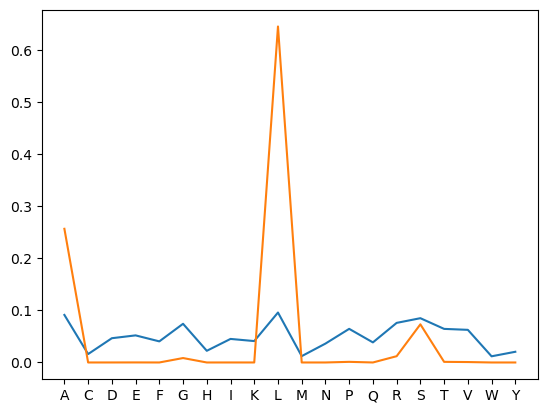

In [39]:
Bf = lp_forward
eBf = np.exp(Bf)
sfeBf = softmax(200*eBf, axis=1)
print(Bf[1], eBf[1], sfeBf[1])
print(np.sum(Bf[1]), np.sum(eBf[1]),np.sum(sfeBf[1]))
x = np.arange(20)

plt.plot(eBf[1])
plt.plot(sfeBf[1])
plt.xticks(x, amino_acids, rotation=0)

IndexError: list index out of range

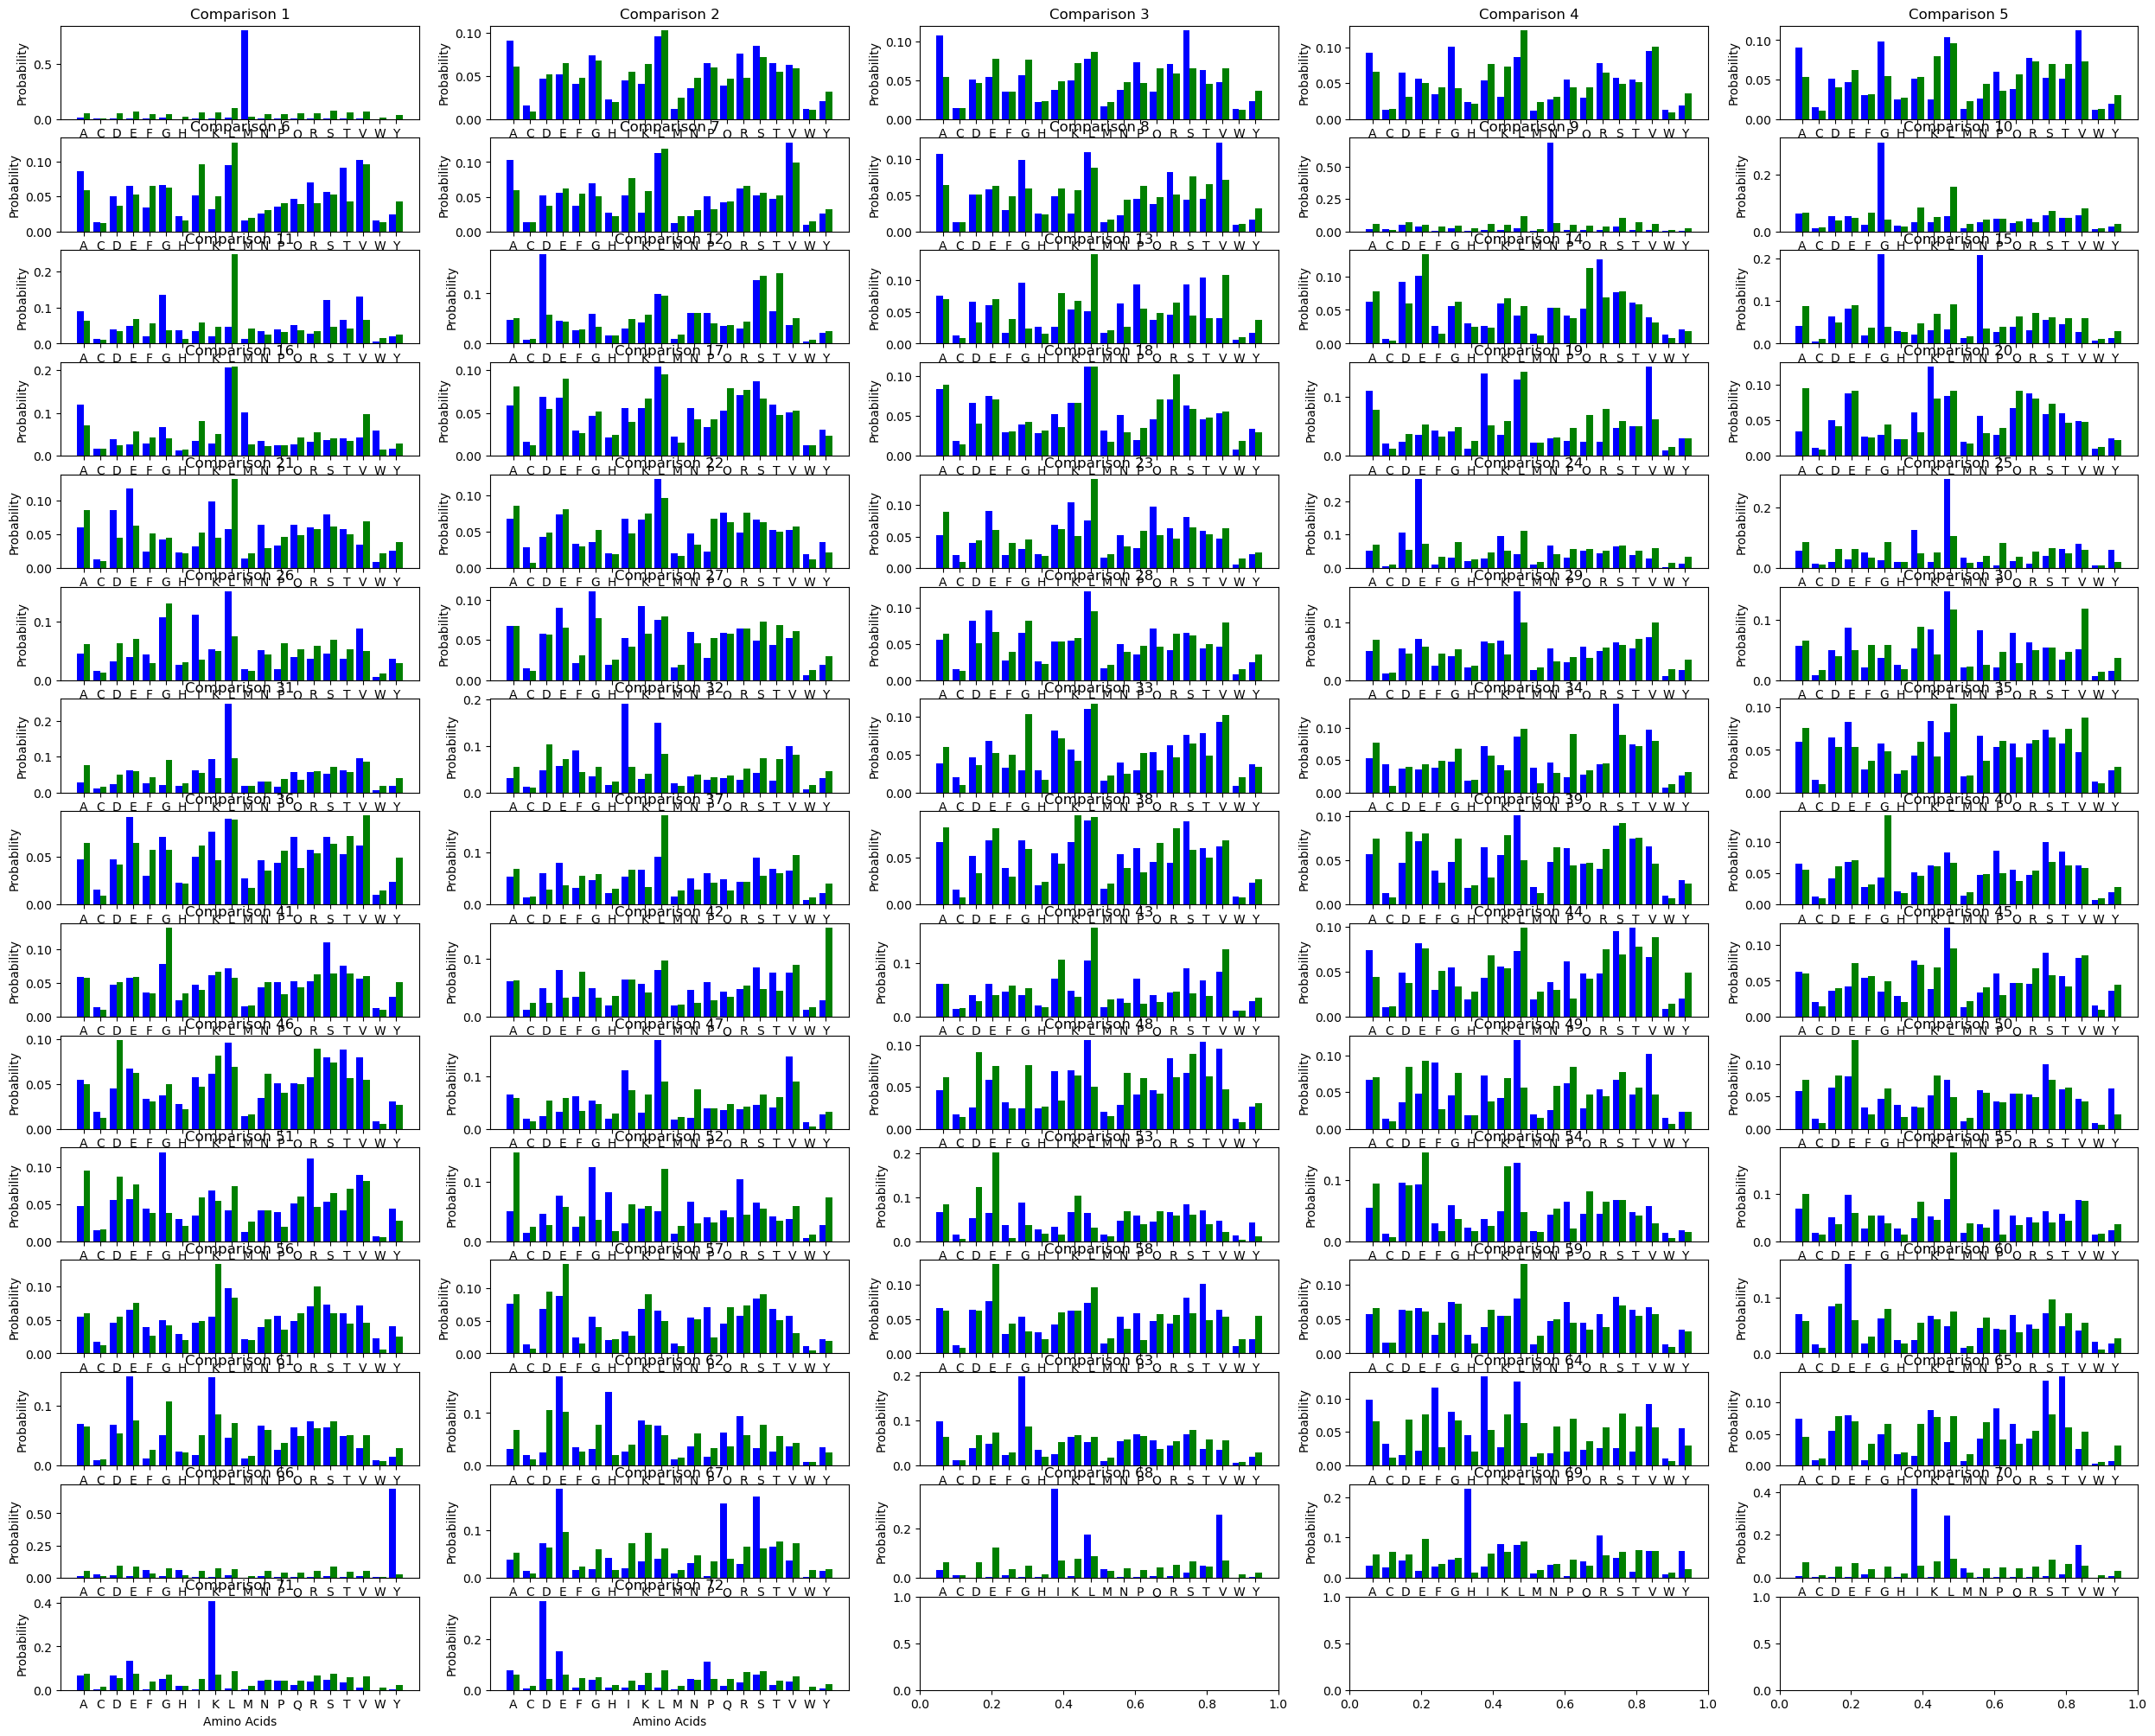

In [22]:
name = 'CBPA2_HUMAN'

A = esm_dict[name]['log_probs']
B = pg_dict[name]['log_probs']
Bf = lp_forward
Bb = lp_backward

eA = np.exp(A)
eB = np.exp(B)
eBf = np.exp(Bf)
eBb = np.exp(Bb)

bound = len(B)

pairs_pgf = [np.array(eBf)[i] for i in range(bound)]
pairs_pgb = [np.array(eBb)[i] for i in range(bound)]

# Plot settings
fig, axes = plt.subplots(15, 5, figsize=(31, 25))
axes = axes.flatten()
bar_width = 0.4
x = torch.arange(1, 21)

for i, ax in enumerate(axes):
    dist1 = pairs_pgf[i]
    dist2 = pairs_pgb[i]
    ax.bar(x - bar_width/2, dist1, width=bar_width, label="Forward", color="blue")
    ax.bar(x + bar_width/2, dist2, width=bar_width, label="Backward", color="green")
    ax.set_title(f"Comparison {i+1}")
    ax.set_xlabel("Amino Acids")
    ax.set_ylabel("Probability")
    # ax.set_ylim(0, 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(aa_list)  
    ax.tick_params(axis='x', rotation=0)

# Add a single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()